# TS2: Modelizando un ADC

**Análisis y Procesamiento de Señales**  
**Daniela Rolando**

## Introducción

En esta tarea se simula el comportamiento de un conversor analógico-digital (ADC), incorporando tanto el muestreo como el proceso de cuantización.

Se considera una señal senoidal contaminada por ruido gaussiano aditivo. La señal de entrada al ADC se modela como:


$$
s_R=s+n
$$


donde $s$ representa la señal senoidal y $n$ el ruido analógico.

La potencia del ruido se establece en relación con la potencia teórica del ruido de cuantización:


$$
P_n=k_nP_q
$$


siendo:


$$
P_q=\frac{q^2}{12}
$$


El ADC trabaja a una frecuencia de muestreo de $f_s=1000$ Hz y presenta un rango analógico de $\pm V_F=2$ V.

En primer lugar se analiza un ADC de 4 bits con $k_n=1$. Posteriormente se estudia una segunda configuración de 8 bits y se comparan los resultados. Finalmente se incluye un análisis adicional de la relación entre el número de bits y el SNR.

## 1. Librerías y parámetros generales

La frecuencia de la señal se fija en:


$$
f_0=\frac{f_s}{N}=\Delta f=1\text{ Hz}
$$


La amplitud de la senoide se toma igual a $\sqrt{2}$, de manera que su potencia sea unitaria.

In [18]:
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from scipy import stats

plt.close('all')

# Parámetros generales
fs = 1000              # frecuencia de muestreo [Hz]
N = 1000               # número de muestras
delta_f = fs / N       # resolución espectral [Hz]

# Señal senoidal
Vmax = np.sqrt(2)      # amplitud para potencia unitaria
dc = 0
ff = delta_f           # f0 = fs/N = 1 Hz
ph = 0

# ADC
Vfs = 2                # rango analógico +/- 2 V

# Media del ruido
ur = 0

# Semilla para repetir la misma realización
np.random.seed(1)

## 2. Funciones utilizadas

Se definen las funciones necesarias para generar la señal senoidal, generar el ruido gaussiano y simular el funcionamiento del ADC para distintos valores de $B$ y $k_n$.

In [19]:
def gen_sin(Vmax=Vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs):
    tt = np.arange(nn) / fs
    xx = dc + Vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx


def gen_noise(Pn, ur=0, nn=N):
    # La potencia del ruido es igual a su varianza
    desv_est_r = np.sqrt(Pn)
    ruido = np.random.normal(ur, desv_est_r, nn)
    return ruido


def simular_adc(B, kn, semilla=1):
    np.random.seed(semilla)

    # Paso de cuantización siguiendo la convención usada en la consigna
    qq = Vfs / (2**B)

    # Potencias de ruido
    Pq = qq**2 / 12
    Pn = kn * Pq

    # Generación de la señal y el ruido
    tt, xx = gen_sin(Vmax, dc, ff, ph, N, fs)
    ruido = gen_noise(Pn, ur, N)

    # Entrada y salida del ADC
    noisy_xx = xx + ruido
    xx_q = np.round(noisy_xx / qq) * qq

    # Ruido de cuantización
    nq = xx_q - noisy_xx

    return tt, xx, ruido, noisy_xx, xx_q, nq, qq, Pq, Pn

# 3. a): ADC de 4 bits y $k_n=1$

Para el primer experimento se utiliza un ADC de **4 bits** y se establece:


$$
k_n=1
$$


Por tanto:


$$
P_n=P_q
$$


La señal senoidal se contamina con ruido gaussiano y posteriormente se cuantiza.

In [20]:
B = 4
kn = 1

tt, xx, ruido, noisy_xx, xx_q, nq, qq, Pq, Pn = simular_adc(B, kn)

print("Configuración del apartado a)")
print("--------------------------------")
print("Número de bits:", B)
print("kn:", kn)
print("Paso de cuantización q =", qq, "V")
print("Potencia teórica del ruido de cuantización =", Pq, "V²")
print("Potencia del ruido analógico =", Pn, "V²")

Configuración del apartado a)
--------------------------------
Número de bits: 4
kn: 1
Paso de cuantización q = 0.125 V
Potencia teórica del ruido de cuantización = 0.0013020833333333333 V²
Potencia del ruido analógico = 0.0013020833333333333 V²


### 3.1. Representación temporal

Se representan la señal analógica original, la señal ruidosa que entra en el ADC y la señal cuantizada a la salida.

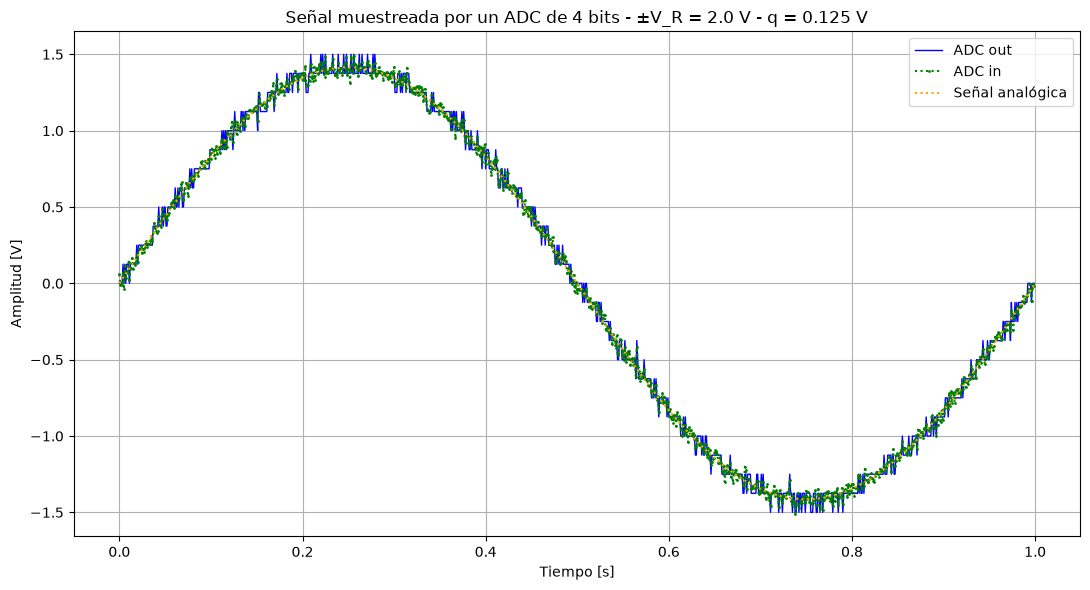

In [21]:
plt.figure(figsize=(11, 6))

plt.plot(tt, xx_q, color='blue', linewidth=1, label='ADC out')
plt.plot(tt, noisy_xx, ':', marker='.', markersize=2,
         color='green', label='ADC in')
plt.plot(tt, xx, ':', color='orange', linewidth=1.5,
         label='Señal analógica')

plt.title(
    'Señal muestreada por un ADC de 4 bits - ±V_R = 2.0 V - q = %.3f V'
    % qq
)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 3.2. Ruido de cuantización

El ruido de cuantización se obtiene como:


$$
n_q=s_Q-s_R
$$


Para un cuantizador ideal se espera una media aproximadamente nula y una varianza cercana a:


$$
\sigma_{n_q}^2=\frac{q^2}{12}
$$


También se espera que sus valores se distribuyan aproximadamente entre $-q/2$ y $q/2$.

In [22]:
media_nq = np.mean(nq)
var_nq = np.var(nq)
var_teorica = qq**2 / 12

print("Características del ruido de cuantización")
print("------------------------------------------")
print("Media =", media_nq, "V")
print("Varianza experimental =", var_nq, "V²")
print("Varianza teórica q²/12 =", var_teorica, "V²")

Características del ruido de cuantización
------------------------------------------
Media = -0.0007755245974163718 V
Varianza experimental = 0.0013273986200263187 V²
Varianza teórica q²/12 = 0.0013020833333333333 V²


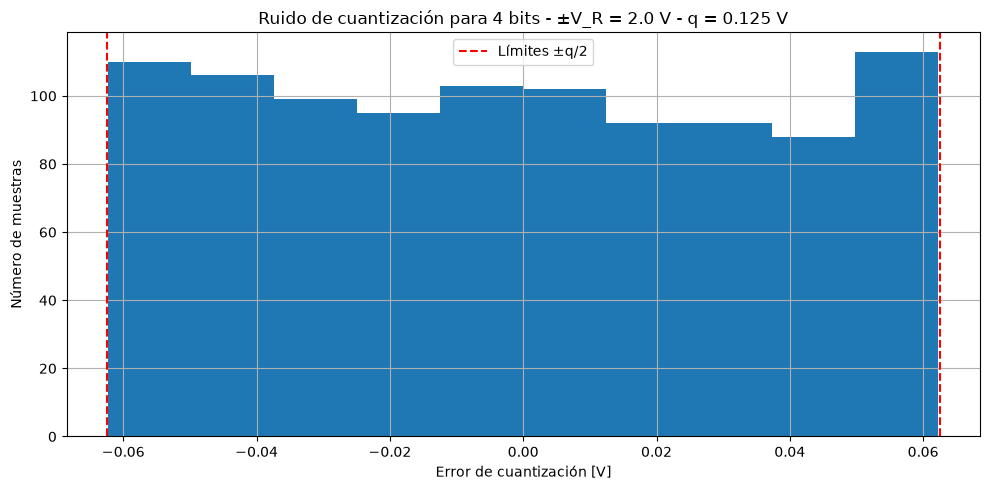

In [23]:
plt.figure(figsize=(10, 5))

plt.hist(nq, bins=10, density=False)
plt.axvline(-qq/2, color='red', linestyle='--', label='Límites ±q/2')
plt.axvline(qq/2, color='red', linestyle='--')

plt.title(
    'Ruido de cuantización para 4 bits - ±V_R = 2.0 V - q = %.3f V'
    % qq
)
plt.xlabel('Error de cuantización [V]')
plt.ylabel('Número de muestras')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

El histograma permite comprobar visualmente que el error de cuantización se mantiene dentro del intervalo esperado. Para complementar esta observación se aplica un test de Kolmogorov-Smirnov, contrastando la compatibilidad de las muestras con una distribución uniforme.

In [24]:
D, pvalor = stats.kstest(
    nq,
    'uniform',
    args=(-qq/2, qq)
)

print("Test de Kolmogorov-Smirnov")
print("---------------------------")
print("Estadístico D =", D)
print("p-valor =", pvalor)

if pvalor > 0.05:
    print("No se rechaza H0: el ruido es compatible con una distribución uniforme.")
else:
    print("Se rechaza H0 para esta realización.")

Test de Kolmogorov-Smirnov
---------------------------
Estadístico D = 0.02042740932378423
p-valor = 0.7902323391440115
No se rechaza H0: el ruido es compatible con una distribución uniforme.


### 3.3. Análisis espectral

Se estudia el comportamiento en frecuencia mediante la DFT. La representación se limita al intervalo comprendido entre 0 Hz y Nyquist:


$$
f_N=\frac{f_s}{2}=500\text{ Hz}
$$


Se muestran la salida del ADC, el ruido analógico y el ruido de cuantización, junto con el valor medio de cada piso de ruido.

In [25]:
# FFT
XX_q = (1/N) * np.fft.fft(xx_q)
NN = (1/N) * np.fft.fft(ruido)
NQ = (1/N) * np.fft.fft(nq)

# Vector de frecuencias hasta Nyquist
frec = np.arange(N//2) * fs/N

# Potencias espectrales
pot_q = 2 * np.abs(XX_q[:N//2])**2
pot_n = 2 * np.abs(NN[:N//2])**2
pot_nq = 2 * np.abs(NQ[:N//2])**2

eps = 1e-20

PSD_q = 10 * np.log10(pot_q + eps)
PSD_n = 10 * np.log10(pot_n + eps)
PSD_nq = 10 * np.log10(pot_nq + eps)

# Piso medio, excluyendo continua
piso_analog = 10 * np.log10(np.mean(pot_n[1:]) + eps)
piso_digital = 10 * np.log10(np.mean(pot_nq[1:]) + eps)

print("Piso medio del ruido analógico =", piso_analog, "dB")
print("Piso medio del ruido de cuantización =", piso_digital, "dB")

Piso medio del ruido analógico = -56.001486306770126 dB
Piso medio del ruido de cuantización = -55.75925069476921 dB


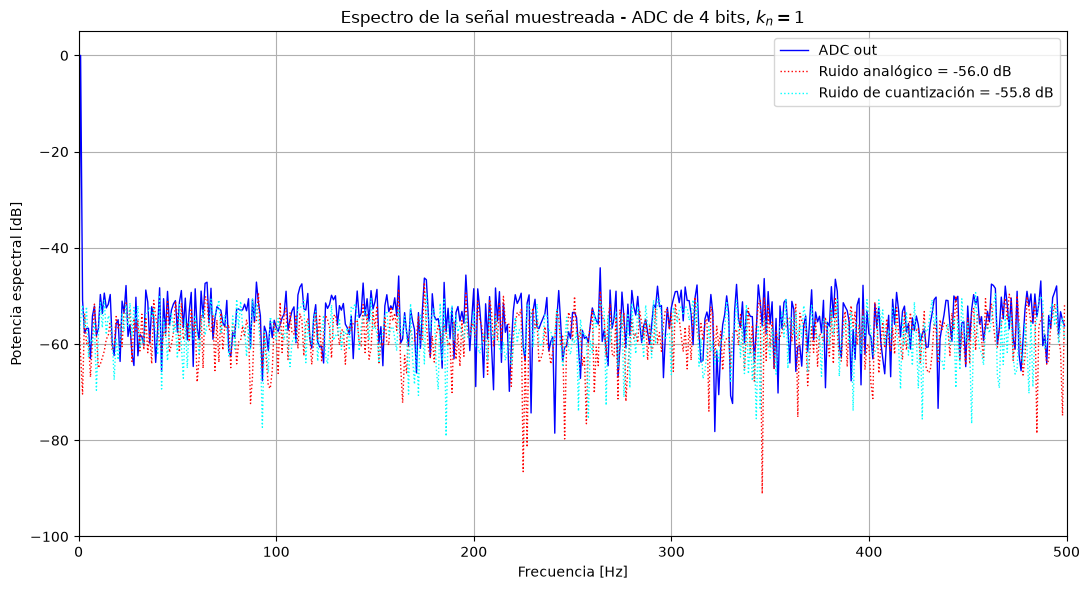

In [35]:
plt.figure(figsize=(11, 6))

plt.plot(frec, PSD_q, color='blue', linewidth=1, label='ADC out')
plt.plot(frec, PSD_n, color='red', linestyle=':', linewidth=1,
         label='Ruido analógico = %.1f dB' % piso_analog)
plt.plot(frec, PSD_nq, color='cyan', linestyle=':', linewidth=1,
         label='Ruido de cuantización = %.1f dB' % piso_digital)

plt.title('Espectro de la señal muestreada - ADC de 4 bits, $k_n=1$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia espectral [dB]')
plt.xlim(0, fs/2)
plt.ylim(-100, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 3.4. Autocorrelación del ruido de cuantización

Si el ruido de cuantización es aproximadamente incorrelado, su autocorrelación debe presentar un máximo en retardo cero y valores próximos a cero para retardos diferentes de cero.

Además, el valor en el origen debe ser próximo a la potencia del ruido de cuantización.

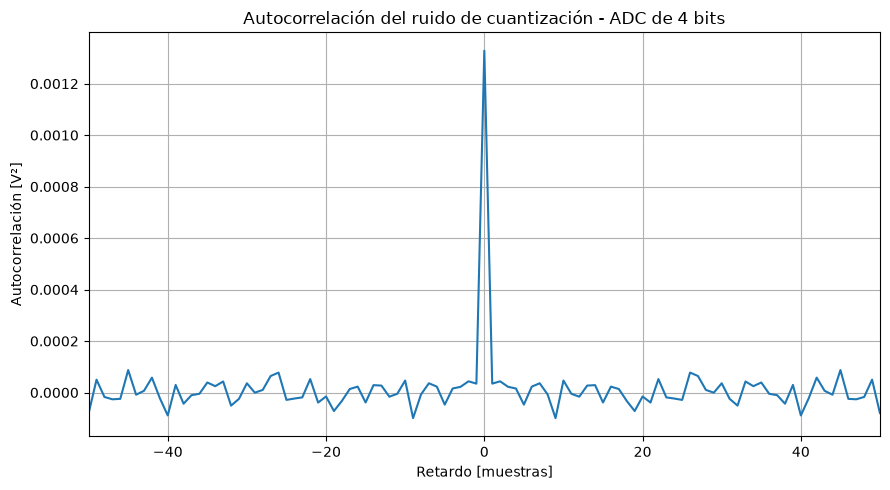

Autocorrelación para retardo cero = 0.0013280000584275167 V²
Potencia teórica q²/12 = 0.0013020833333333333 V²


In [27]:
autocorr = np.correlate(nq, nq, mode='full') / N
lags = np.arange(-N + 1, N)

plt.figure(figsize=(9, 5))
plt.plot(lags, autocorr)

plt.title('Autocorrelación del ruido de cuantización - ADC de 4 bits')
plt.xlabel('Retardo [muestras]')
plt.ylabel('Autocorrelación [V²]')
plt.xlim(-50, 50)
plt.grid(True)
plt.tight_layout()
plt.show()

R0 = autocorr[N-1]

print("Autocorrelación para retardo cero =", R0, "V²")
print("Potencia teórica q²/12 =", Pq, "V²")

# 4. b): ADC de 8 bits y $k_n=1$

Como segunda configuración se selecciona:


$$
B=8\text{ bits},\qquad k_n=1
$$


Al aumentar el número de bits disminuye el paso de cuantización. Puesto que $P_q=q^2/12$, también se espera una disminución importante de la potencia del ruido de cuantización.

In [28]:
B_b = 8
kn_b = 1

tt_b, xx_b, ruido_b, noisy_xx_b, xx_q_b, nq_b, qq_b, Pq_b, Pn_b = simular_adc(
    B_b, kn_b, semilla=1
)

print("Configuración del apartado b)")
print("--------------------------------")
print("Número de bits:", B_b)
print("kn:", kn_b)
print("Paso de cuantización q =", qq_b, "V")
print("Potencia teórica del ruido de cuantización =", Pq_b, "V²")
print("Potencia del ruido analógico =", Pn_b, "V²")

Configuración del apartado b)
--------------------------------
Número de bits: 8
kn: 1
Paso de cuantización q = 0.0078125 V
Potencia teórica del ruido de cuantización = 5.086263020833333e-06 V²
Potencia del ruido analógico = 5.086263020833333e-06 V²


### 4.1. Representación temporal

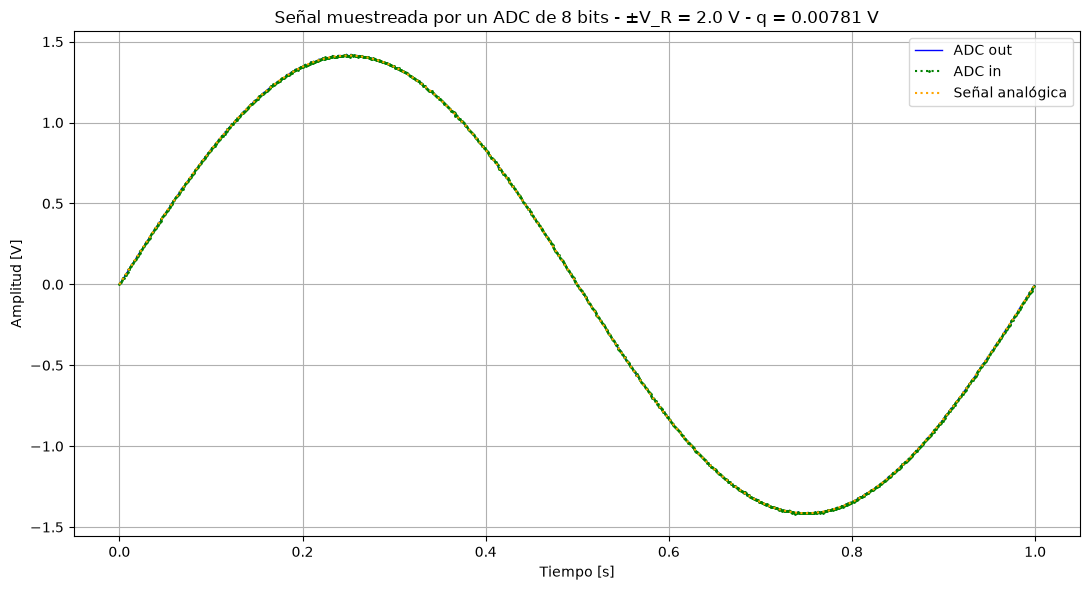

In [29]:
plt.figure(figsize=(11, 6))

plt.plot(tt_b, xx_q_b, color='blue', linewidth=1, label='ADC out')
plt.plot(tt_b, noisy_xx_b, ':', marker='.', markersize=2,
         color='green', label='ADC in')
plt.plot(tt_b, xx_b, ':', color='orange', linewidth=1.5,
         label='Señal analógica')

plt.title(
    'Señal muestreada por un ADC de 8 bits - ±V_R = 2.0 V - q = %.5f V'
    % qq_b
)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 4.2. Histograma del ruido de cuantización

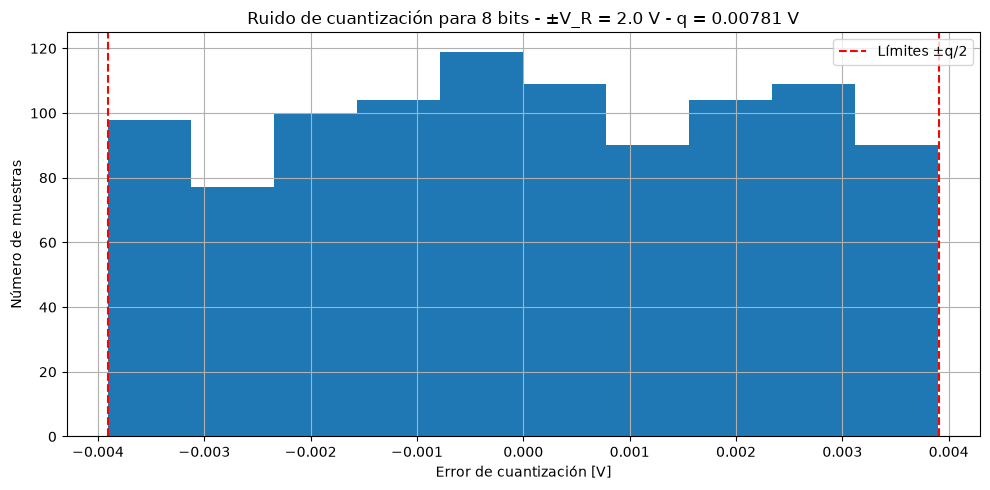

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(nq_b, bins=10, density=False)
plt.axvline(-qq_b/2, color='red', linestyle='--', label='Límites ±q/2')
plt.axvline(qq_b/2, color='red', linestyle='--')

plt.title(
    'Ruido de cuantización para 8 bits - ±V_R = 2.0 V - q = %.5f V'
    % qq_b
)
plt.xlabel('Error de cuantización [V]')
plt.ylabel('Número de muestras')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3. Análisis espectral

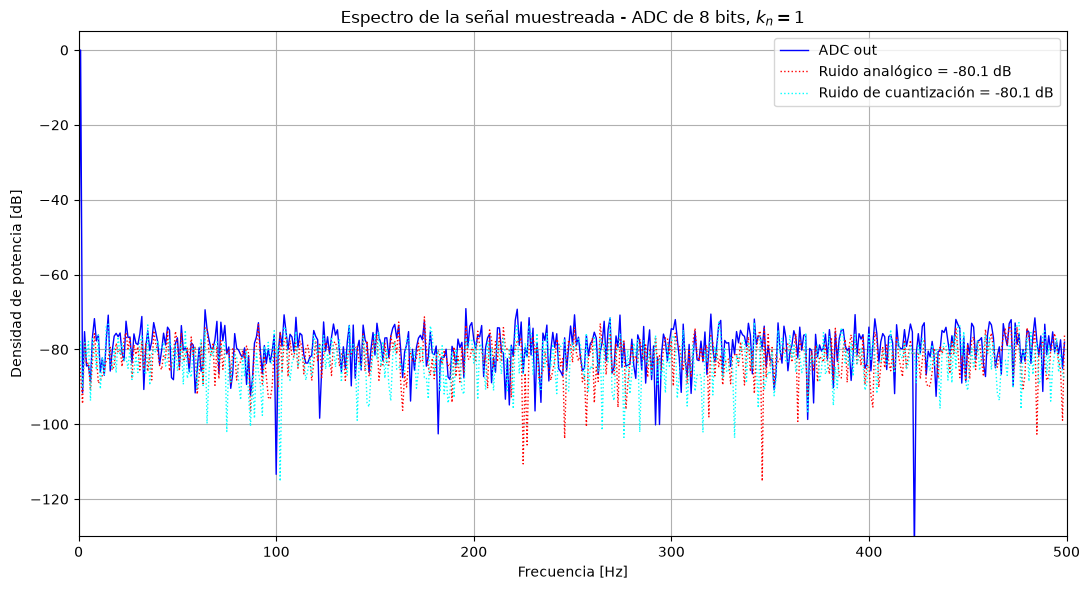

Piso medio del ruido analógico = -80.08388595988421 dB
Piso medio del ruido de cuantización = -80.1456598198744 dB


In [31]:
XX_q_b = (1/N) * np.fft.fft(xx_q_b)
NN_b = (1/N) * np.fft.fft(ruido_b)
NQ_b = (1/N) * np.fft.fft(nq_b)

pot_q_b = 2 * np.abs(XX_q_b[:N//2])**2
pot_n_b = 2 * np.abs(NN_b[:N//2])**2
pot_nq_b = 2 * np.abs(NQ_b[:N//2])**2

PSD_q_b = 10 * np.log10(pot_q_b + eps)
PSD_n_b = 10 * np.log10(pot_n_b + eps)
PSD_nq_b = 10 * np.log10(pot_nq_b + eps)

piso_analog_b = 10 * np.log10(np.mean(pot_n_b[1:]) + eps)
piso_digital_b = 10 * np.log10(np.mean(pot_nq_b[1:]) + eps)

plt.figure(figsize=(11, 6))

plt.plot(frec, PSD_q_b, color='blue', linewidth=1, label='ADC out')
plt.plot(frec, PSD_n_b, color='red', linestyle=':', linewidth=1,
         label='Ruido analógico = %.1f dB' % piso_analog_b)
plt.plot(frec, PSD_nq_b, color='cyan', linestyle=':', linewidth=1,
         label='Ruido de cuantización = %.1f dB' % piso_digital_b)

plt.title('Espectro de la señal muestreada - ADC de 8 bits, $k_n=1$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB]')
plt.xlim(0, fs/2)
plt.ylim(-130, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Piso medio del ruido analógico =", piso_analog_b, "dB")
print("Piso medio del ruido de cuantización =", piso_digital_b, "dB")

### 4.4. Comparación con el apartado a)

Al aumentar la resolución del ADC de 4 a 8 bits disminuye considerablemente el paso de cuantización.

Debido a que:


$$
P_q=\frac{q^2}{12},
$$


la disminución de $q$ provoca también una reducción de la potencia del ruido de cuantización.

En las representaciones se observa que el error de cuantización presenta una amplitud menor para el ADC de 8 bits. En el dominio frecuencial, el piso de ruido también aparece a un nivel inferior.

Por tanto, el aumento del número de bits permite representar la señal con mayor resolución y reduce el efecto producido por la cuantización.

In [32]:
var_nq_b = np.var(nq_b)

print("Comparación numérica")
print("--------------------")
print("4 bits:")
print("  q =", qq, "V")
print("  Varianza experimental =", var_nq, "V²")
print("  Pq teórica =", Pq, "V²")
print("  Piso analógico =", piso_analog, "dB")
print("  Piso digital =", piso_digital, "dB")
print()
print("8 bits:")
print("  q =", qq_b, "V")
print("  Varianza experimental =", var_nq_b, "V²")
print("  Pq teórica =", Pq_b, "V²")
print("  Piso analógico =", piso_analog_b, "dB")
print("  Piso digital =", piso_digital_b, "dB")

Comparación numérica
--------------------
4 bits:
  q = 0.125 V
  Varianza experimental = 0.0013273986200263187 V²
  Pq teórica = 0.0013020833333333333 V²
  Piso analógico = -56.001486306770126 dB
  Piso digital = -55.75925069476921 dB

8 bits:
  q = 0.0078125 V
  Varianza experimental = 4.826764575862711e-06 V²
  Pq teórica = 5.086263020833333e-06 V²
  Piso analógico = -80.08388595988421 dB
  Piso digital = -80.1456598198744 dB


# 5. Bonus: relación entre el número de bits y el SNR

Se estudia la relación entre la cantidad de bits del ADC y la relación señal-ruido asociada al proceso de cuantización.

El paso de cuantización depende del número de bits según:

$$
q=\frac{V_F}{2^B}
$$

y la potencia teórica del ruido de cuantización es:

$$
P_q=\frac{q^2}{12}.
$$

Como la senoide utilizada tiene potencia unitaria, el SNR debido exclusivamente a la cuantización puede calcularse como:

$$
SNR_q=10\log_{10}\left(\frac{1}{P_q}\right).
$$

Sustituyendo la expresión de \(q\):

$$
SNR_q=
10\log_{10}\left(\frac{12\,2^{2B}}{V_F^2}\right).
$$

Para el rango utilizado en esta tarea, \(V_F=2\) V, se obtiene:

$$
\boxed{SNR_q \approx 6.02\,B + 4.77\ \text{dB}}
$$

Por tanto, idealmente, añadir un bit de resolución supone una mejora aproximada de 6 dB en el SNR de cuantización. A continuación se comprueba esta relación para ADC de 4, 8 y 16 bits.

In [33]:
bits = np.array([4, 8, 16])

SNR_teorico = []
SNR_simulado = []
q_valores = []

for B_aux in bits:
    q_aux = Vfs / (2**B_aux)
    q_valores.append(q_aux)

    Pq_aux = q_aux**2 / 12

    # Potencia de la señal senoidal = 1
    snr_teo = 10 * np.log10(1 / Pq_aux)
    SNR_teorico.append(snr_teo)

    # Simulación considerando únicamente el error de cuantización
    tt_aux, xx_aux = gen_sin(Vmax, dc, ff, ph, N, fs)

    xx_q_aux = np.round(xx_aux / q_aux) * q_aux
    nq_aux = xx_q_aux - xx_aux

    P_signal_aux = np.mean(xx_aux**2)
    P_noise_aux = np.mean(nq_aux**2)

    snr_sim = 10 * np.log10(P_signal_aux / P_noise_aux)
    SNR_simulado.append(snr_sim)

SNR_teorico = np.array(SNR_teorico)
SNR_simulado = np.array(SNR_simulado)
q_valores = np.array(q_valores)

# Tabla comparativa solicitada en el bonus
html = """
<table style="border-collapse: collapse; text-align: center;">
    <tr>
        <th style="border:1px solid #999; padding:6px 12px;">B [bits]</th>
        <th style="border:1px solid #999; padding:6px 12px;">q [V]</th>
        <th style="border:1px solid #999; padding:6px 12px;">SNR teórico [dB]</th>
        <th style="border:1px solid #999; padding:6px 12px;">SNR simulado [dB]</th>
    </tr>
"""

for i in range(len(bits)):
    html += f"""
    <tr>
        <td style="border:1px solid #999; padding:6px 12px;">{bits[i]}</td>
        <td style="border:1px solid #999; padding:6px 12px;">{q_valores[i]:.8f}</td>
        <td style="border:1px solid #999; padding:6px 12px;">{SNR_teorico[i]:.2f}</td>
        <td style="border:1px solid #999; padding:6px 12px;">{SNR_simulado[i]:.2f}</td>
    </tr>
"""

html += "</table>"

print("Tabla comparativa del SNR:")
display(HTML(html))

Tabla comparativa del SNR:


B [bits],q [V],SNR teórico [dB],SNR simulado [dB]
4,0.12500000,28.85,29.14
8,0.00781250,52.94,53.39
16,0.00003052,101.10,101.12


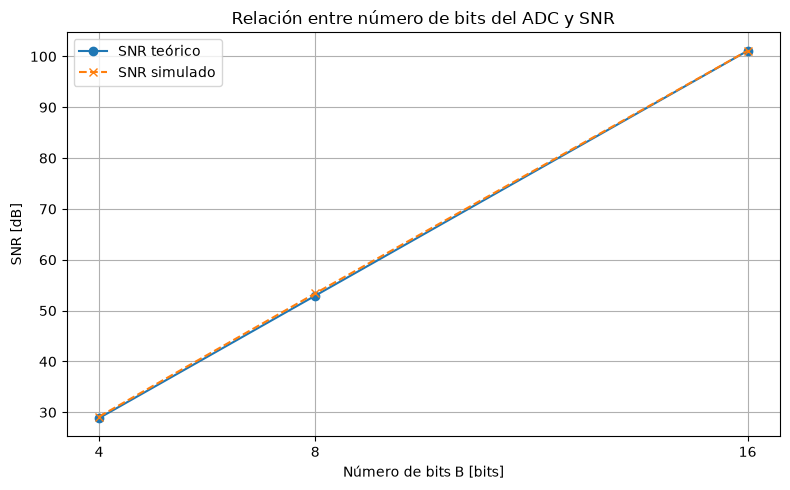

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(bits, SNR_teorico, 'o-', label='SNR teórico')
plt.plot(bits, SNR_simulado, 'x--', label='SNR simulado')

plt.title('Relación entre número de bits del ADC y SNR')
plt.xlabel('Número de bits B [bits]')
plt.ylabel('SNR [dB]')
plt.xticks(bits)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Resultado y discusión del bonus

Los resultados teóricos y simulados presentan una concordancia muy buena para los tres números de bits analizados.

- Para **4 bits**, el paso de cuantización es relativamente grande y el SNR es el menor de los tres casos.
- Para **8 bits**, el paso de cuantización disminuye de forma considerable y el SNR aumenta aproximadamente 24 dB respecto al caso de 4 bits.
- Para **16 bits**, el error de cuantización es muy pequeño y el SNR alcanza un valor muy elevado.

La evolución obtenida confirma la relación teórica:

$$
SNR_q \approx 6.02\,B + 4.77\ \text{dB}.
$$

Por tanto, el SNR aumenta aproximadamente **6 dB por cada bit adicional** de resolución en un ADC ideal.

# 6. Conclusiones

En esta tarea se ha simulado el comportamiento de un ADC teniendo en cuenta el muestreo, la presencia de ruido analógico y el proceso de cuantización.

Para el ADC de 4 bits con \(k_n=1\) se ha comprobado que el error de cuantización presenta una media próxima a cero y una varianza cercana al valor teórico \(q^2/12\). El histograma muestra además un comportamiento aproximadamente uniforme dentro del intervalo comprendido entre \(-q/2\) y \(q/2\).

El análisis de la autocorrelación presenta un máximo en retardo cero y valores considerablemente menores para el resto de retardos, comportamiento compatible con un ruido de cuantización aproximadamente incorrelado.

En el apartado b) se ha seleccionado la configuración de 8 bits con \(k_n=1\). Mantener el mismo valor de \(k_n\) permite estudiar principalmente el efecto del aumento de resolución. Al pasar de 4 a 8 bits disminuyen el paso y la potencia del ruido de cuantización, obteniéndose una representación digital de mayor resolución y un piso de ruido menor.

Finalmente, en el bonus se ha estudiado la relación entre el número de bits y el SNR para 4, 8 y 16 bits. La tabla comparativa y la representación gráfica muestran una buena concordancia entre los resultados teóricos y simulados. Se verifica que, para el modelo utilizado,

$$
SNR_q \approx 6.02\,B + 4.77\ \text{dB},
$$

por lo que cada bit adicional proporciona aproximadamente 6 dB de mejora en el SNR de cuantización.

En conclusión, el número de bits del ADC determina directamente su resolución y tiene una influencia fundamental sobre la potencia del ruido de cuantización y la calidad de la señal digitalizada.